In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Definitions ---

# Define the set of possible time slots (Day + Time)
TIME_SLOTS = [
    "Mon 9:00",
    "Mon 11:00",
    "Tue 9:00",
    "Tue 11:00",
    "Wed 9:00",
    "Wed 11:00",
    "Thu 9:00",
    "Thu 11:00",
]

# Define the available classrooms and their properties
ROOMS = {
    "R101": {"capacity": 35, "equipment": ["Projector"]},
    "R205": {"capacity": 50, "equipment": ["Projector", "Whiteboard"]},
    "LAB_A": {"capacity": 20, "equipment": ["Lab Equipment", "Projector"]},
    "AUD_B": {"capacity": 100, "equipment": ["Projector", "Audio System"]},
}

# Define the courses (Variables) and their properties
COURSES_DATA = {
    "CS101": {
        "instructor": "Dr. Smith",
        "enrollment": 30,
        "students": ["S1", "S2", "S5"],
        "equipment_req": ["Projector"],
    },
    "PHY200": {
        "instructor": "Prof. Jones",
        "enrollment": 45,
        "students": ["S1", "S3", "S6"],
        "equipment_req": ["Projecter"],
    },
    "MATH101": {
        "instructor": "Dr. Smith",
        "enrollment": 25,
        "students": ["S2", "S4", "S5"],
        "equipment_req": [],
    },
    "BIO300": {
        "instructor": "Dr. Chen",
        "enrollment": 18,
        "students": ["S3", "S4", "S6"],
        "equipment_req": ["Lab Equipment"],
    },
    "ENG101": {
        "instructor": "Prof. Jones",
        "enrollment": 80,
        "students": ["S1", "S2", "S3"],
        "equipment_req": ["Audio System"],
    },
    "HIS100": {
        "instructor": "Dr. Patel",
        "enrollment": 30,
        "students": ["S4", "S5", "S6"],
        "equipment_req": [],
    },
}

# Variables for the CSP
COURSES = list(COURSES_DATA.keys())

# --- 2. Domains Creation (Manual Loop) ---
DOMAINS = {}
room_ids = list(ROOMS.keys())
for course_id in COURSES:
    course_domain = []
    # Manually create the Cartesian product of Time Slots and Rooms
    for time_slot in TIME_SLOTS:
        for room_id in room_ids:
            # A domain value is a tuple: (time_slot, room_id)
            course_domain.append((time_slot, room_id))
    DOMAINS[course_id] = course_domain

# --- 3. Constraint Checking Function (No Change) ---


def is_consistent(course_id, assignment_value, assignment):
    """
    Checks if assigning assignment_value (time, room) to course_id is consistent
    with the current partial assignment based on all four constraints.
    """
    time_slot, room_id = assignment_value

    course_info = COURSES_DATA[course_id]
    instructor = course_info["instructor"]
    enrollment = course_info["enrollment"]
    req_equipment = set(course_info["equipment_req"])

    room_info = ROOMS[room_id]
    room_capacity = room_info["capacity"]
    room_equipment = set(room_info["equipment"])

    # 1. Room Capacity Constraint
    if enrollment > room_capacity:
        return False

    # 2. Room Equipment Constraint
    if not req_equipment.issubset(room_equipment):
        return False

    for other_course_id, (other_time, other_room) in assignment.items():

        # 3. Instructor Conflict Constraint
        other_instructor = COURSES_DATA[other_course_id]["instructor"]
        if instructor == other_instructor and time_slot == other_time:
            return False

        # 4. Student Conflict Constraint
        course_students = set(course_info["students"])
        other_students = set(COURSES_DATA[other_course_id]["students"])
        common_students = course_students.intersection(other_students)

        if common_students and (time_slot == other_time):
            return False

    return True


# --- 4. CSP Backtracking Solver (No Change) ---


def select_unassigned_variable(assignment):
    for course in COURSES:
        if course not in assignment:
            return course
    return None


def csp_backtracking(assignment):
    if len(assignment) == len(COURSES):
        return assignment

    course_id = select_unassigned_variable(assignment)
    if course_id is None:
        return assignment

    for value in DOMAINS[course_id]:
        if is_consistent(course_id, value, assignment):
            assignment[course_id] = value
            result = csp_backtracking(assignment)

            if result is not False:
                return result

            del assignment[course_id]

    return False


# ------------------------------------------------------------
# --- 5. Matplotlib Visualization Function (CORRECTED) ---
# ------------------------------------------------------------


def visualize_schedule(schedule):
    """
    Creates a Matplotlib visualization of the course schedule as a Timetable Grid.
    CORRECTION: Changed table.get_celld(r, c) to table.get_celld((r, c))
    to fix the 'takes 1 positional argument but 2 were given' TypeError.
    """
    if not schedule:
        print("No schedule to visualize.")
        return

    # 1. Data Processing for Plotting
    room_ids = list(ROOMS.keys())
    grid_data = np.full((len(room_ids), len(TIME_SLOTS)), "", dtype=object)

    time_slot_to_index = {slot: i for i, slot in enumerate(TIME_SLOTS)}
    room_to_index = {room: i for i, room in enumerate(room_ids)}

    instructors = sorted(list(set(d["instructor"] for d in COURSES_DATA.values())))
    colors = plt.cm.get_cmap("Pastel1", len(instructors))
    instructor_color_map = {inst: colors(i) for i, inst in enumerate(instructors)}

    # Populate the grid
    for course_id, (time_slot, room_id) in schedule.items():
        if time_slot not in time_slot_to_index:
            continue

        r_idx = room_to_index[room_id]
        t_idx = time_slot_to_index[time_slot]

        instructor = COURSES_DATA[course_id]["instructor"]
        enrollment = COURSES_DATA[course_id]["enrollment"]
        capacity = ROOMS[room_id]["capacity"]

        text = f"{course_id}\n" f"({instructor})\n" f"Cap: {enrollment}/{capacity}"

        grid_data[r_idx, t_idx] = text

    # 2. Matplotlib Visualization Setup
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.set_title("University Course Schedule (CSP Solution)", fontsize=16, pad=20)

    table = ax.table(
        cellText=grid_data,
        rowLabels=room_ids,
        colLabels=TIME_SLOTS,
        cellLoc="center",
        loc="center",
    )

    # Styling and Coloring the Cells
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width(col=list(range(len(TIME_SLOTS))))

    # Color the data cells (r, c)
    for r in range(len(room_ids)):
        for c in range(len(TIME_SLOTS)):
            course_text = grid_data[r, c]
            if course_text:
                course_id = course_text.split("\n")[0]
                instructor = COURSES_DATA.get(course_id, {}).get("instructor")
                color = instructor_color_map.get(instructor, "lightgray")
                cell = table.get_celld((r, c))
                cell.set_facecolor(color)
                cell.set_edgecolor("black")

    # Style row/column headers
    # Row Headers (Rooms): (r, -1)
    for i in range(len(room_ids)):
        cell = table.get_celld((i, -1))
        cell.set_facecolor("lightgray")

    # Column Headers (Time Slots): (-1, j)
    for j in range(len(TIME_SLOTS)):
        cell = table.get_celld((-1, j))
        cell.set_facecolor("lightblue")

    # Remove axis ticks and labels
    ax.axis("off")

    # Add a legend for the instructor colors
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=instructor_color_map[inst], ec="k")
        for inst in instructors
    ]
    ax.legend(
        legend_handles,
        instructors,
        title="Instructor",
        loc="upper right",
        bbox_to_anchor=(1.25, 1.0),
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# --- Main Execution ---
# ------------------------------------------------------------
if __name__ == "__main__":

    print("Starting CSP Solver for Course Scheduling...")

    final_schedule = csp_backtracking({})

    if final_schedule:
        print("\n✅ Success! A valid schedule was found. Generating visualization...")
        visualize_schedule(final_schedule)
    else:
        print(
            "\n❌ FAILED: No valid schedule could be found under the given constraints and domains."
        )

Starting CSP Solver for Course Scheduling...

❌ FAILED: No valid schedule could be found under the given constraints and domains.


Starting Max-CSP Solver for Guest Seating...
Maximum possible soft score (preferences satisfied): 7

✅ Success! An optimal seating arrangement found.
Final Max Score: 5

--- Final Seating Assignment ---
T1 (Capacity 2/8): Bob, Eve
T2 (Capacity 3/10): Alice, Charlie, David
T3 (Capacity 2/6): Frank, Grace
T4 (Capacity 0/8): 

Generating enhanced visualization...


/tmp/ipython-input-1139708312.py:188: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for side text
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


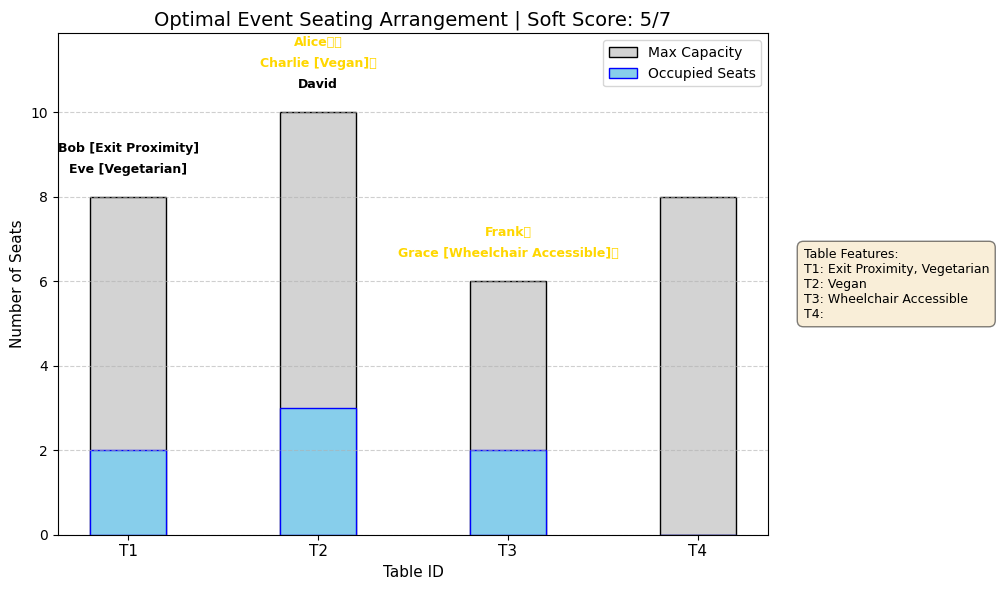

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Definitions (No Change) ---

# Define the available tables and their hard constraints
TABLES = {
    "T1": {"capacity": 8, "features": ["Exit Proximity", "Vegetarian"]},
    "T2": {"capacity": 10, "features": ["Vegan"]},
    "T3": {"capacity": 6, "features": ["Wheelchair Accessible"]},
    "T4": {"capacity": 8, "features": []},
}
TABLE_IDS = list(TABLES.keys())

# Define the guests and their soft/hard constraints
GUESTS_DATA = {
    "Alice": {"avoid": ["Bob", "Eve"], "prefer": ["Charlie", "David"], "needs": []},
    "Bob": {"avoid": ["Alice"], "prefer": ["David"], "needs": ["Exit Proximity"]},
    "Charlie": {"avoid": [], "prefer": ["Alice"], "needs": ["Vegan"]},
    "David": {"avoid": ["Eve"], "prefer": ["Bob"], "needs": []},
    "Eve": {"avoid": ["Alice", "David"], "prefer": [], "needs": ["Vegetarian"]},
    "Frank": {"avoid": [], "prefer": ["Grace"], "needs": []},
    "Grace": {"avoid": [], "prefer": ["Frank"], "needs": ["Wheelchair Accessible"]},
}

GUESTS = list(GUESTS_DATA.keys())
GUEST_DOMAIN = TABLE_IDS

# Global tracking for Max-CSP optimization
BEST_ASSIGNMENT = None
MAX_SCORE = -1
MAX_POSSIBLE_SCORE = sum(len(GUESTS_DATA[g]["prefer"]) for g in GUESTS)

# --- 2. Constraint Checking and Scoring (No Change) ---


def check_hard_constraints(guest_name, table_id, assignment):
    """Checks Avoidance, Capacity, and Accommodation constraints."""

    current_table_occupants = [g for g, t in assignment.items() if t == table_id]
    if len(current_table_occupants) >= TABLES[table_id]["capacity"]:
        return False

    guest_needs = set(GUESTS_DATA[guest_name]["needs"])
    table_features = set(TABLES[table_id]["features"])
    if not guest_needs.issubset(table_features):
        return False

    guest_avoids = set(GUESTS_DATA[guest_name]["avoid"])

    for other_guest in current_table_occupants:
        if other_guest in guest_avoids:
            return False
        if guest_name in GUESTS_DATA[other_guest]["avoid"]:
            return False

    return True


def calculate_score(final_assignment):
    """Calculates the soft constraint score based on satisfied preferences."""
    score = 0
    for guest, assigned_table in final_assignment.items():
        for preferred_guest in GUESTS_DATA[guest]["prefer"]:
            if (
                preferred_guest in final_assignment
                and final_assignment[preferred_guest] == assigned_table
            ):
                score += 1
    return score


# --- 3. Max-CSP Backtracking Solver (No Change) ---


def select_unassigned_variable(assignment):
    for guest in GUESTS:
        if guest not in assignment:
            return guest
    return None


def max_csp_backtracking(assignment):
    global MAX_SCORE, BEST_ASSIGNMENT

    if len(assignment) == len(GUESTS):
        current_score = calculate_score(assignment)
        if current_score > MAX_SCORE:
            MAX_SCORE = current_score
            BEST_ASSIGNMENT = assignment.copy()
        return True

    guest = select_unassigned_variable(assignment)
    if guest is None:
        return True

    for table_id in GUEST_DOMAIN:
        if check_hard_constraints(guest, table_id, assignment):
            assignment[guest] = table_id
            max_csp_backtracking(assignment)
            del assignment[guest]

    return False


# --- 4. Matplotlib Visualization (Revised) ---


def visualize_seating(final_assignment):
    """
    Creates a Matplotlib visualization showing table capacity usage and guest preferences.
    """
    if not final_assignment:
        print("No assignment to visualize.")
        return

    # Map tables to their guests and calculate stats
    table_map = {tid: [] for tid in TABLE_IDS}
    for guest, table_id in final_assignment.items():
        table_map[table_id].append(guest)

    # Prepare data for plotting
    table_names = list(TABLES.keys())
    capacities = [TABLES[tid]["capacity"] for tid in table_names]
    occupancies = [len(table_map[tid]) for tid in table_names]

    # Calculate preference score for labeling
    def get_guest_label(guest, table_id):
        satisfied_prefs = 0
        for pref in GUESTS_DATA[guest]["prefer"]:
            if pref in final_assignment and final_assignment[pref] == table_id:
                satisfied_prefs += 1

        # Determine visual marker (Soft Constraint)
        marker = "⭐" * satisfied_prefs if satisfied_prefs > 0 else ""

        # Determine needs marker (Hard Constraint Check)
        needs_text = (
            f" [{', '.join(GUESTS_DATA[guest]['needs'])}]"
            if GUESTS_DATA[guest]["needs"]
            else ""
        )

        return f"{guest}{needs_text}{marker}"

    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # 1. Bar Chart for Capacity
    bar_width = 0.4
    r1 = np.arange(len(table_names))

    # Plot Capacity
    ax.bar(
        r1,
        capacities,
        color="lightgray",
        width=bar_width,
        edgecolor="black",
        label="Max Capacity",
    )
    # Plot Occupancy
    ax.bar(
        r1,
        occupancies,
        color="skyblue",
        width=bar_width,
        edgecolor="blue",
        label="Occupied Seats",
    )

    # 2. Add Guest Labels and Preference Icons
    for i, table_id in enumerate(table_names):
        guests = table_map[table_id]

        # Sort guests to ensure consistent vertical spacing
        guests.sort(key=lambda g: get_guest_label(g, table_id), reverse=True)

        y_offset = capacities[i] + 0.5  # Start labeling slightly above the max bar

        for guest in guests:
            label = get_guest_label(guest, table_id)

            # Use 'gold' for guests who satisfied preferences for visibility
            color = "gold" if "⭐" in label else "black"

            ax.text(
                r1[i],
                y_offset,
                label,
                ha="center",
                va="bottom",
                fontsize=9,
                color=color,
                weight="bold",
            )
            y_offset += 0.5  # Move label position up

    # 3. Final Styling and Labels

    # Add Table Features to the bottom of the axis
    features_labels = [", ".join(TABLES[tid]["features"]) for tid in table_names]
    features_text = "\n".join(
        [f"{tid}: {feat}" for tid, feat in zip(table_names, features_labels)]
    )

    # Add table features and final score summary outside the main plot area
    ax.text(
        1.05,
        0.5,
        "Table Features:\n" + features_text,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5),
    )

    ax.set_xticks(r1)
    ax.set_xticklabels(table_names, fontsize=11)
    ax.set_ylabel("Number of Seats", fontsize=11)
    ax.set_xlabel("Table ID", fontsize=11)
    ax.set_title(
        f"Optimal Event Seating Arrangement | Soft Score: {MAX_SCORE}/{MAX_POSSIBLE_SCORE}",
        fontsize=14,
    )
    ax.legend(loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Set Y-limit slightly higher than the highest capacity to fit all labels
    max_height = max(capacities) + 0.5 * (
        len(GUESTS) / len(TABLE_IDS) + 2
    )  # dynamic height
    ax.set_ylim(0, max_height)

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make room for side text
    plt.show()


# ------------------------------------------------------------
# --- Main Execution ---
# ------------------------------------------------------------
if __name__ == "__main__":

    print(f"Starting Max-CSP Solver for Guest Seating...")
    print(f"Maximum possible soft score (preferences satisfied): {MAX_POSSIBLE_SCORE}")

    # Run the backtracking search
    max_csp_backtracking({})

    if BEST_ASSIGNMENT:
        print(f"\n✅ Success! An optimal seating arrangement found.")
        print(f"Final Max Score: {MAX_SCORE}")

        # Print the detailed assignment (console output)
        print("\n--- Final Seating Assignment ---")
        for table_id in TABLE_IDS:
            guests = [g for g, t in BEST_ASSIGNMENT.items() if t == table_id]
            print(
                f"{table_id} (Capacity {len(guests)}/{TABLES[table_id]['capacity']}): {', '.join(guests)}"
            )

        print("\nGenerating enhanced visualization...")
        visualize_seating(BEST_ASSIGNMENT)

    else:
        print(
            "\n❌ FAILED: No valid seating arrangement could be found that satisfies all hard constraints."
        )